<a href="https://colab.research.google.com/github/PraiseOrly/COVID-19_ClinicalTrials/blob/main/Diagnosis_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **THE DATASET**



In [ ]:
#Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
drive.mount('/content/drive')
import os
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
#load data
data = pd.read_csv('/content/drive/MyDrive/Mission Capstone/Diagnosis/heart_2020_cleaned.csv')
data.head(10)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No
6,No,21.63,No,No,No,15.0,0.0,No,Female,70-74,White,No,Yes,Fair,4.0,Yes,No,Yes
7,No,31.64,Yes,No,No,5.0,0.0,Yes,Female,80 or older,White,Yes,No,Good,9.0,Yes,No,No
8,No,26.45,No,No,No,0.0,0.0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5.0,No,Yes,No
9,No,40.69,No,No,No,0.0,0.0,Yes,Male,65-69,White,No,Yes,Good,10.0,No,No,No


# **EXPLORATIVE ANALYSIS**

In [ ]:
# Dimension of the dataset
row, col = data.shape
print(f"There are {row} registered patients, each one with {col} features to describe their health")

There are 319795 registered patients, each one with 18 features to describe their health


In [ ]:
# Features data types information
data.dtypes

,0
HeartDisease,object
BMI,float64
Smoking,object
AlcoholDrinking,object
Stroke,object
PhysicalHealth,float64
MentalHealth,float64
DiffWalking,object
Sex,object
AgeCategory,object


In [ ]:
# Counting Null and NA values in the dataset
null_values = data.isnull().sum().sum()
na_values = data.isna().sum().sum()

print(f"Null values: {null_values} - NA values: {na_values}")

Null values: 0 - NA values: 0


In [ ]:
# Description of numerical features
data.describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,319795.0,28.325399,6.356100,12.02,24.03,27.34,31.42,94.85
PhysicalHealth,319795.0,3.371710,7.950850,0.00,0.00,0.00,2.00,30.00
MentalHealth,319795.0,3.898366,7.955235,0.00,0.00,0.00,3.00,30.00
SleepTime,319795.0,7.097075,1.436007,1.00,6.00,7.00,8.00,24.00


In [ ]:
# Description of categorical variables
data.describe(include=['O']).T

,count,unique,top,freq
HeartDisease,319795,2,No,292422
Smoking,319795,2,No,187887
AlcoholDrinking,319795,2,No,298018
Stroke,319795,2,No,307726
DiffWalking,319795,2,No,275385
Sex,319795,2,Female,167805
AgeCategory,319795,13,65-69,34151
Race,319795,6,White,245212
Diabetic,319795,4,No,269653
PhysicalActivity,319795,2,Yes,247957


In [ ]:
sorted(list(data["AgeCategory"].unique()))


['18-24',
 '25-29',
 '30-34',
 '35-39',
 '40-44',
 '45-49',
 '50-54',
 '55-59',
 '60-64',
 '65-69',
 '70-74',
 '75-79',
 '80 or older']

In [ ]:
# Check for data types and missing values
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [ ]:
# The binary features are transformed to a numerical (0-1) format

data = data[data.columns].replace({"Yes":1, "Yes (during pregnancy)": 1,"No": 0,
                             "No, borderline diabetes": 0, "Male": 1, "Female": 0})
#data[col_binary] = datacol_binary].astype(np.int8)

In [ ]:
data.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [ ]:
#The features will be categorized based on their format (binary, categorical, and continuous) to facilitate better analysis, while the target feature (output) will be extracted separately for prediction.
y_col = ['HeartDisease']
col_binary = ['Smoking', 'AlcoholDrinking', 'Stroke','DiffWalking', 'Sex','Diabetic',
              'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']
col_categorical = ['AgeCategory','Race','GenHealth']
col_continuous = ['BMI','PhysicalHealth', 'MentalHealth','SleepTime']

In [ ]:
# The categorical features are transformed to a category format
data[col_categorical] = data[col_categorical].astype("category")

In [ ]:
# Validating data types
data.dtypes

,0
HeartDisease,int64
BMI,float64
Smoking,int64
AlcoholDrinking,int64
Stroke,int64
PhysicalHealth,float64
MentalHealth,float64
DiffWalking,int64
Sex,int64
AgeCategory,category


In [ ]:
# Categorical features are omitted to a correlation analysis
data_corr = data.drop(col_categorical, axis = 1)

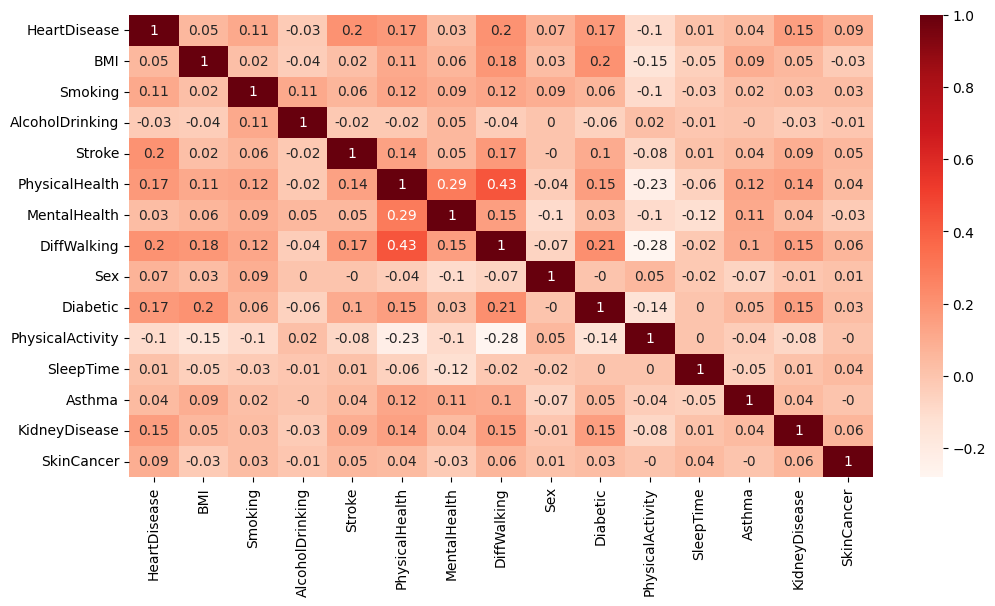

In [ ]:
# Assuming 'data_corr' is your DataFrame
corr = data_corr.corr().round(2)

# Plotting the heatmap correlation between variables
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap='Reds')
plt.show()

The Correlation HeatMap suggests that there isn't a specific condition that directly causes cardiovascular disease.

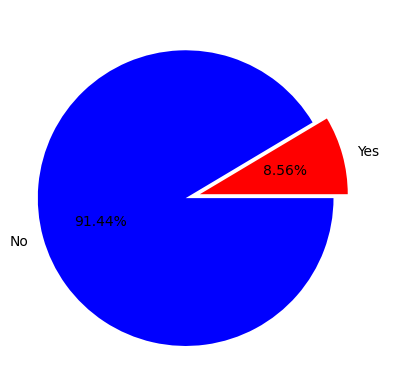

In [ ]:
# Analyzing the percentage of people with a cardiovascular disease
Yes_answer = data[data["HeartDisease"] == 1].shape[0]
No_answer = data[data["HeartDisease"] == 0].shape[0]

# declaring exploding pie
explode = [0, 0.1]

# plotting data on chart with custom colors
plt.pie([Yes_answer, No_answer], labels=["Yes", "No"],
        colors=['red', 'blue'],
        explode=explode, autopct='%.2f%%')

# displaying chart
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def pie_chart_comparison(data, fixed_column, specific_column, category):
    values = ["Yes", "No"]

    # Obtaining each category from the specific column
    if data[specific_column].dtype == 'int64':
        categories = [1, 0]
        size_chart = (12, 9)
    else:
        categories = [op for op in data[specific_column].cat.categories]
        size_chart = (18, 12)

    # Obtaining the quantity of people with a cardiovascular disease per each category
    yes = [data[(data[specific_column] == cat) & (data[fixed_column] == 1)].shape[0] for cat in categories]
    no = [data[(data[specific_column] == cat) & (data[fixed_column] == 0)].shape[0] for cat in categories]

    # declaring exploding pie
    explode = [0, 0.1]

    # plotting data on chart with custom colors
    fig, axs = plt.subplots(1, len(categories), figsize=size_chart)
    for i in range(len(categories)):
        axs[i].pie([yes[i], no[i]], labels=values,
                   colors=['red', 'green'],
                   explode=explode, autopct='%.2f%%')
        axs[i].set_title(f'{category}: {categories[i]}')

    plt.show()

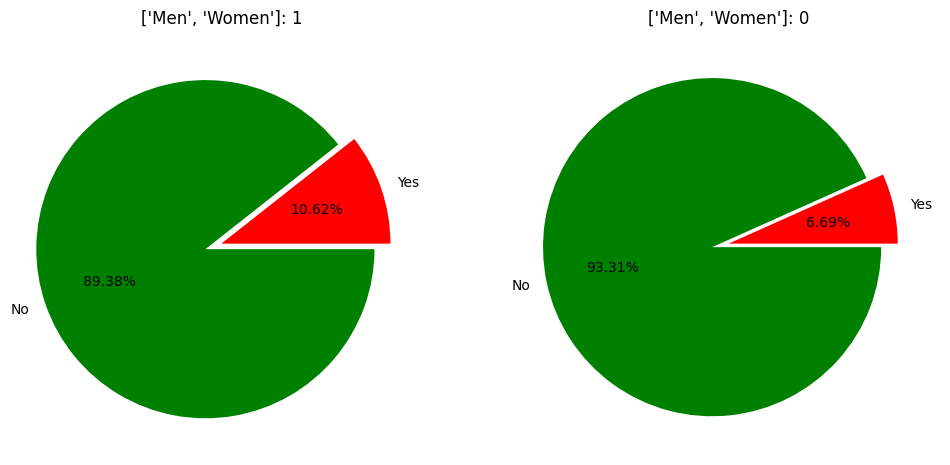

In [ ]:
pie_chart_comparison(data,"HeartDisease","Sex",
                     ["Men","Women"])

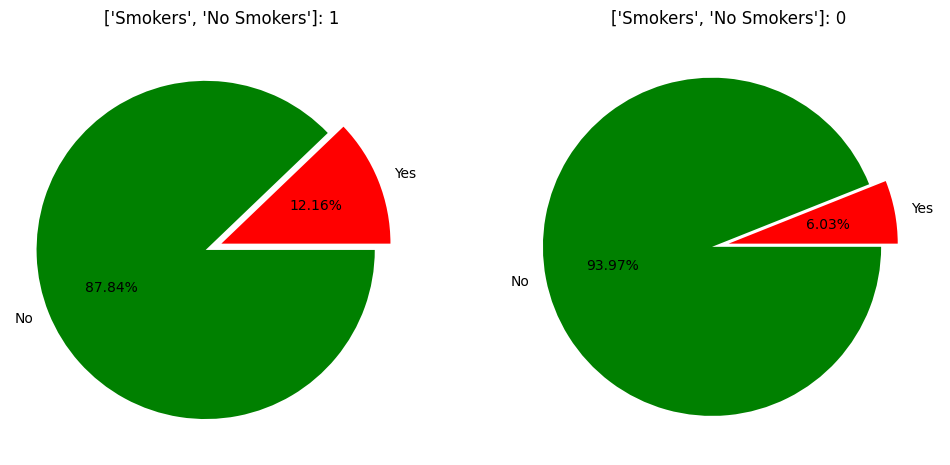

In [ ]:
pie_chart_comparison(data,"HeartDisease","Smoking",
                     ["Smokers","No Smokers"])

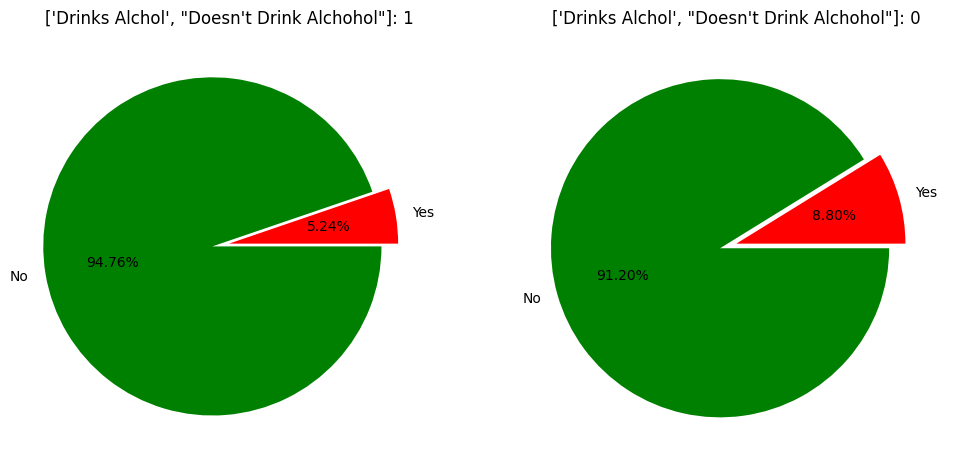

In [ ]:
pie_chart_comparison(data,"HeartDisease","AlcoholDrinking",
                     ["Drinks Alchol","Doesn't Drink Alchohol"])

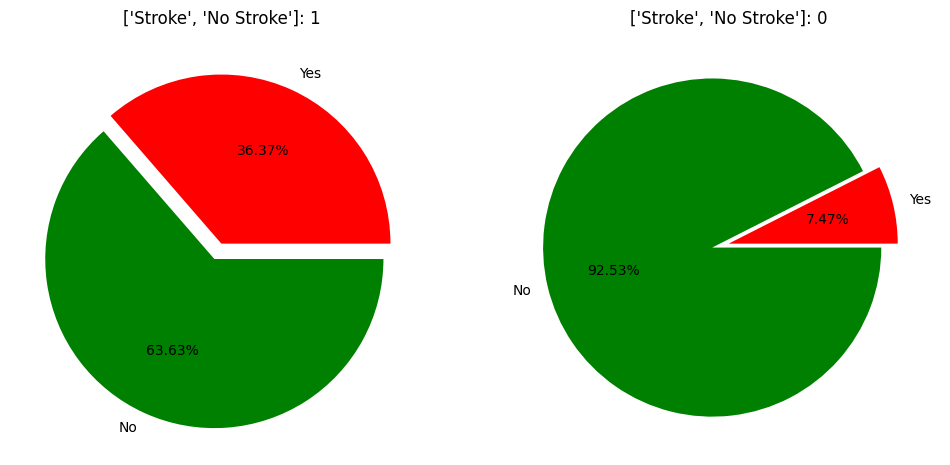

In [ ]:
pie_chart_comparison(data,"HeartDisease","Stroke",
                     ["Stroke","No Stroke"])

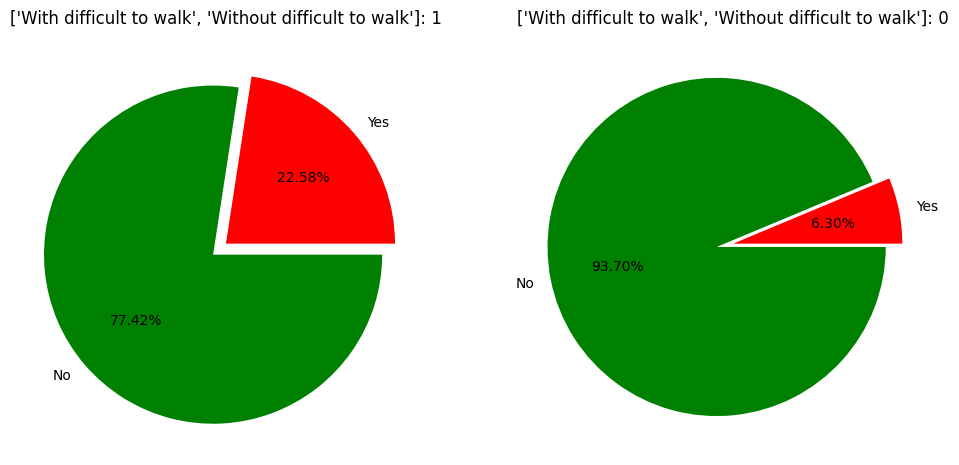

In [ ]:
pie_chart_comparison(data,"HeartDisease","DiffWalking",
                     ["With difficult to walk","Without difficult to walk"])

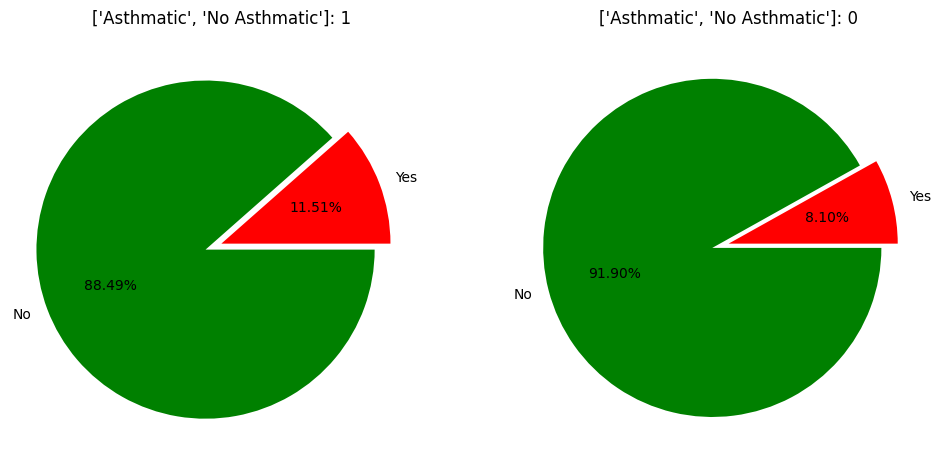

In [ ]:
pie_chart_comparison(data,"HeartDisease","Asthma",
                     ["Asthmatic","No Asthmatic"])

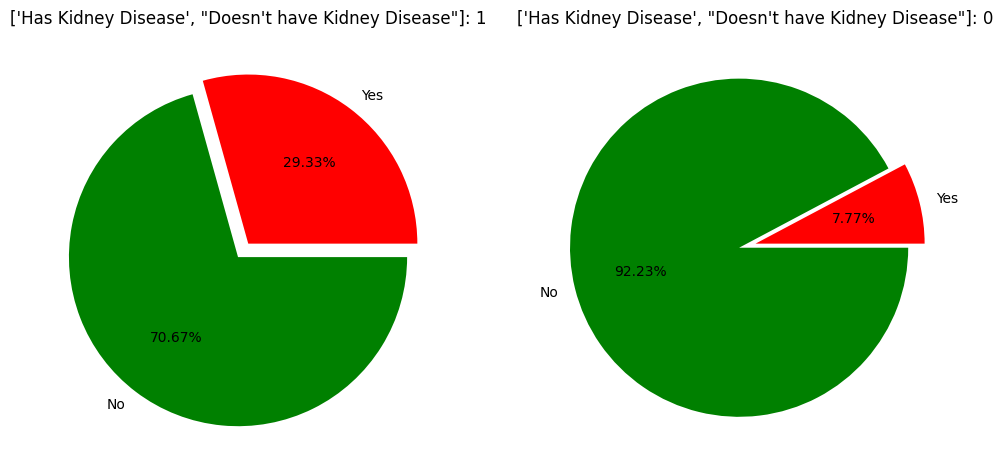

In [ ]:
pie_chart_comparison(data,"HeartDisease","KidneyDisease",
                     ["Has Kidney Disease","Doesn't have Kidney Disease"])

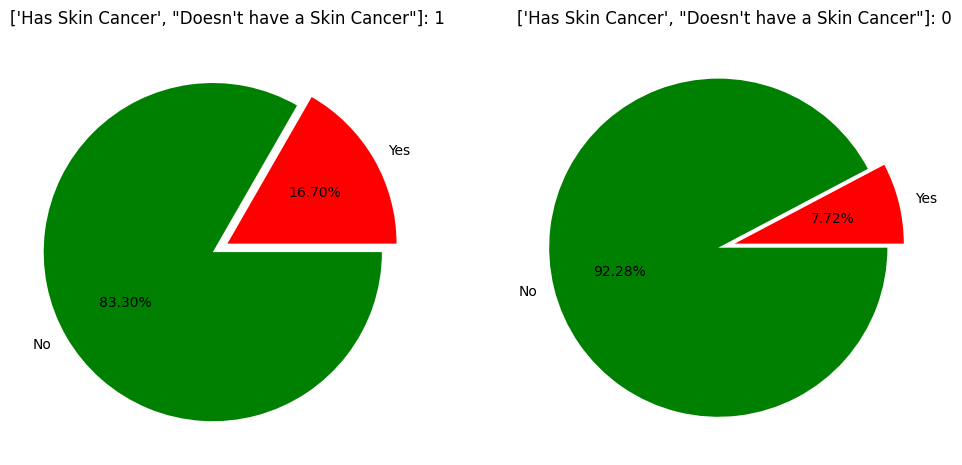

In [ ]:
pie_chart_comparison(data,"HeartDisease","SkinCancer",
                     ["Has Skin Cancer","Doesn't have a Skin Cancer"])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def pie_chart_comparison(data, fixed_column, specific_column, category):
    values = ["Yes", "No"]

    # Obtaining each category from the specific column
    categories = [op for op in data[specific_column].cat.categories]

    # Obtaining the quantity of people with a cardiovascular disease per each category
    yes = [data[(data[specific_column] == cat) & (data[fixed_column] == 1)].shape[0] for cat in categories]
    no = [data[(data[specific_column] == cat) & (data[fixed_column] == 0)].shape[0] for cat in categories]

    # Create a DataFrame for the pie chart data
    comparison = pd.DataFrame([[yes[i], no[i]] for i in range(len(yes))], index=category, columns=values)

    # Create a pie chart for each age category with arrows
    fig, axes = plt.subplots(1, len(comparison.index), figsize=(20, 10))
    for i, (ax, age_group) in enumerate(zip(axes, comparison.index)):
        ax.pie(comparison.loc[age_group], labels=comparison.columns,
               colors=['red', 'green'], autopct='%.2f%%')
        ax.set_title(f'{age_group}')

        # Add arrows
        if i > 0:
            # Draw arrow from previous pie chart to current one
            xy_start = (axes[i-1].get_position().x1, axes[i-1].get_position().y1)  # End of previous pie
            xy_end = (ax.get_position().x0, ax.get_position().y1)  # Start of current pie
            fig.patches.extend([plt.Arrow(xy_start[0], xy_start[1] - 0.1,  # Adjust arrow position
                                          xy_end[0] - xy_start[0], 0,
                                          width=0.02, color='black')])

    plt.show()

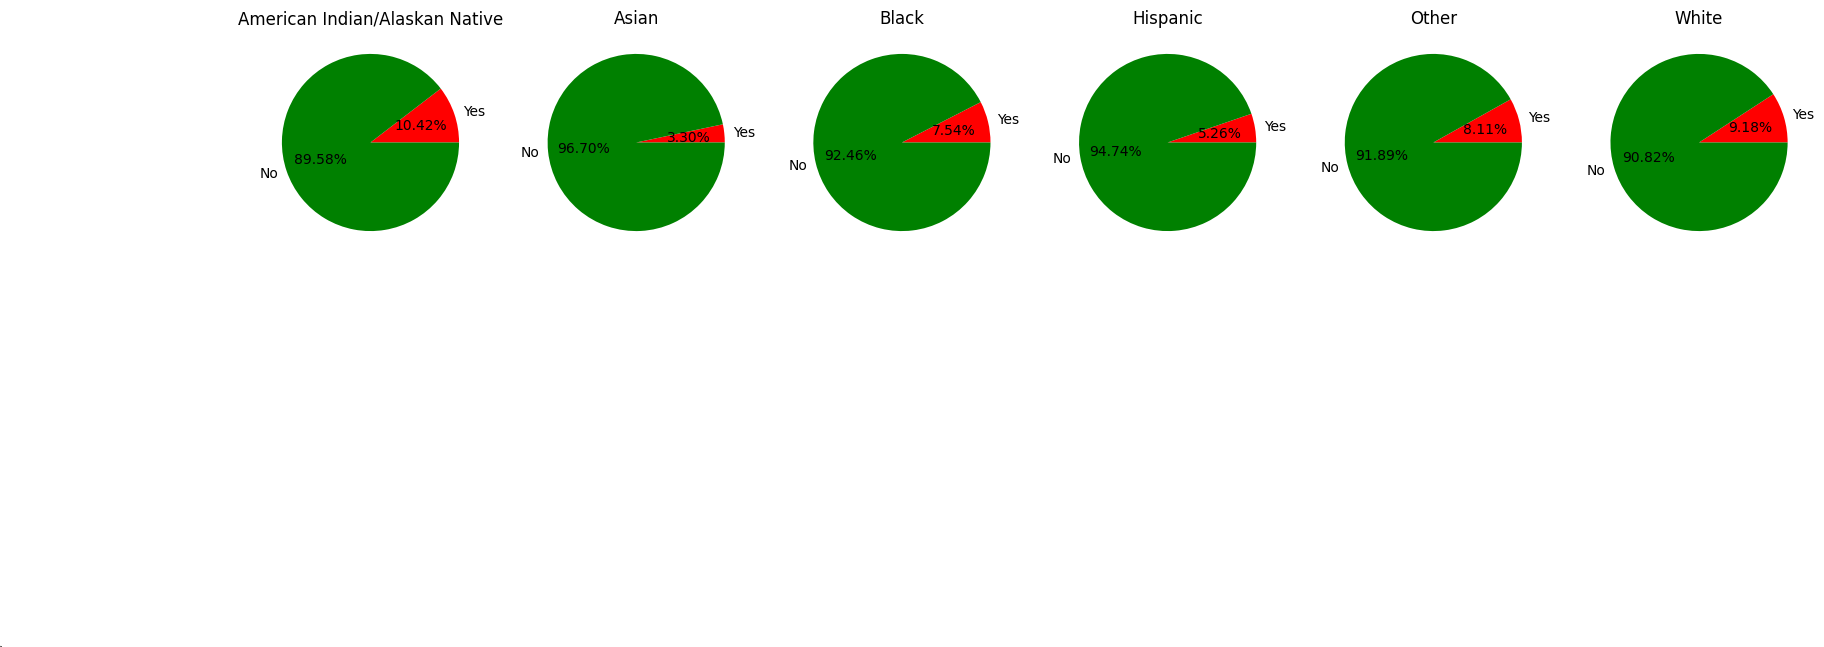

In [ ]:
pie_chart_comparison(data,"HeartDisease","Race",
                     data["Race"].cat.categories)

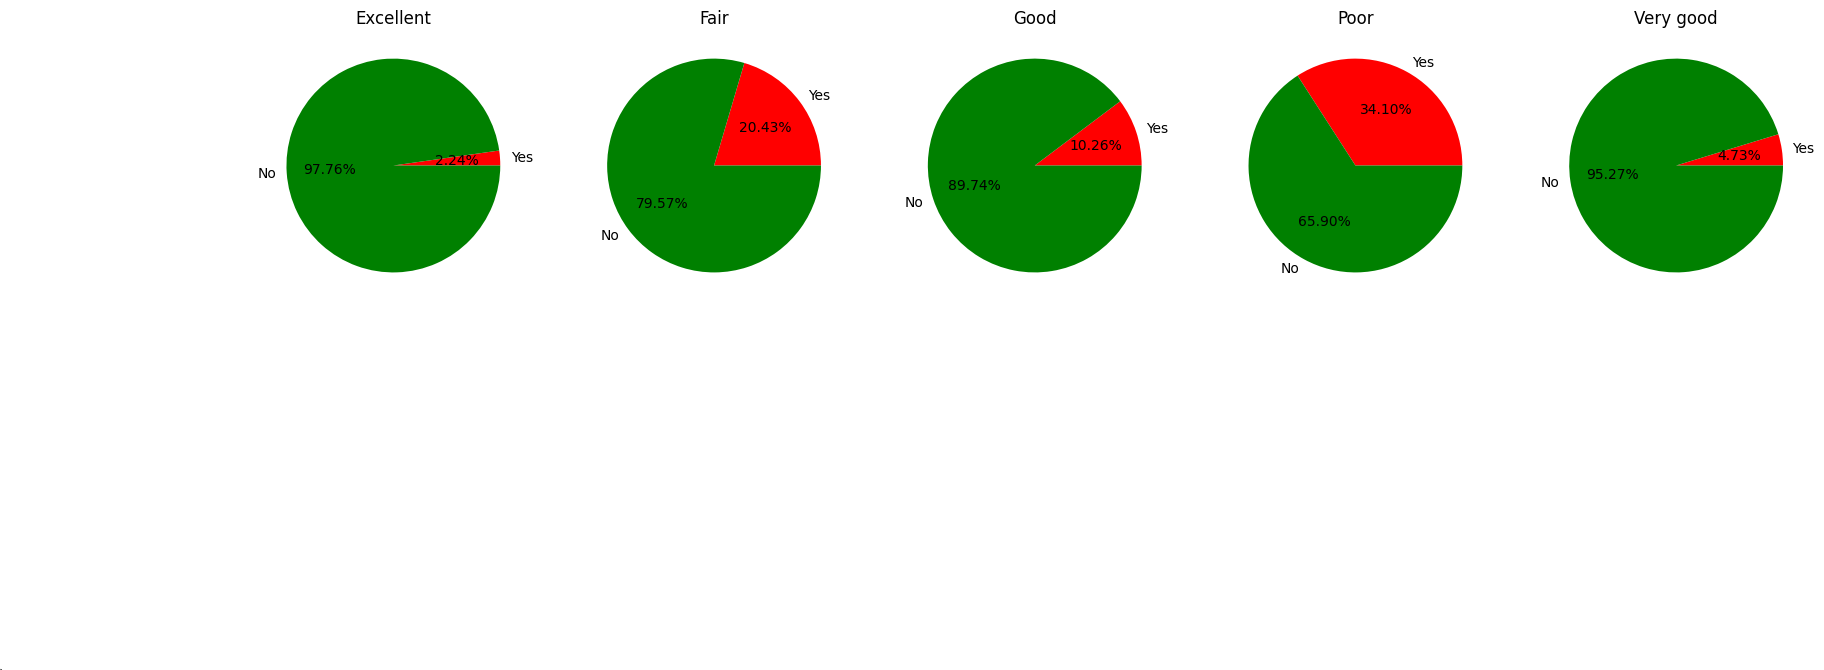

In [ ]:
pie_chart_comparison(data,"HeartDisease","GenHealth",
                     data["GenHealth"].cat.categories)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

def bar_chart_comparison(data, data1, data2):
    total_data = defaultdict(int)
    filter_data = defaultdict(int)

    for i in range(len(data)):
        total_data[int(data[data2][i])] += 1
        filter_data[int(data[data2][i])] += int(data[data1][i])

    values = list(total_data.keys())
    values.sort()

    x = []
    y = []
    for v in values:
        if total_data[v] > 50:
            x.append(v)
            y.append(filter_data[v] / total_data[v])

    # Create a bar chart instead of scatterplot
    plt.bar(x, y)
    plt.xlabel(data2)
    plt.ylabel(f"Proportion of {data1}")
    plt.title(f"Comparison of {data1} by {data2}")
    plt.show()

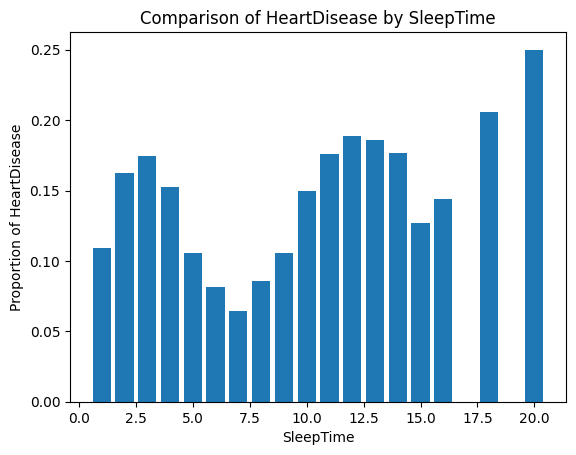

In [ ]:
bar_chart_comparison(data,"HeartDisease","SleepTime")


This proportion indicates that 25% of the individuals within the specific category associated with the sleep time of 20 hours are diagnosed with heart disease.

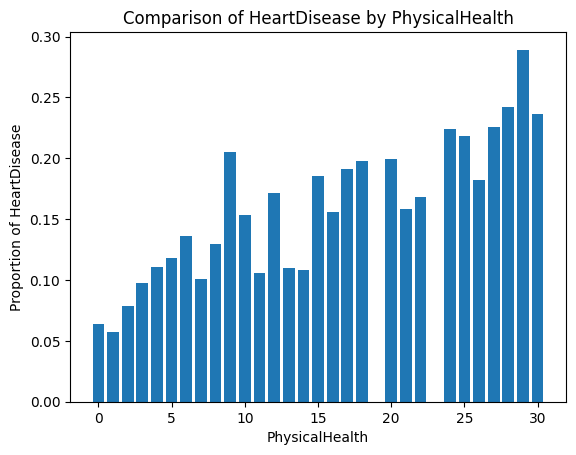

In [ ]:
bar_chart_comparison(data,"HeartDisease","PhysicalHealth")


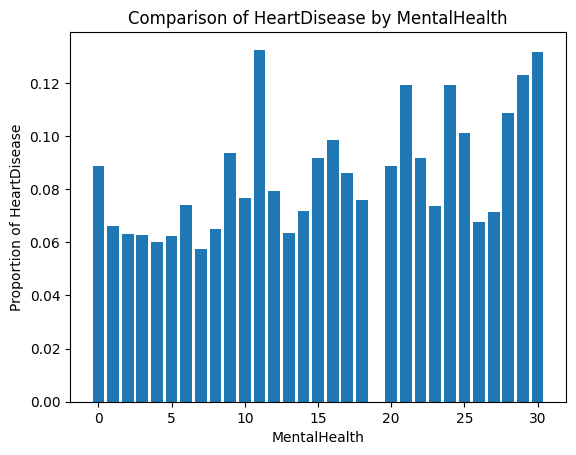

In [ ]:
bar_chart_comparison(data,"HeartDisease","MentalHealth")


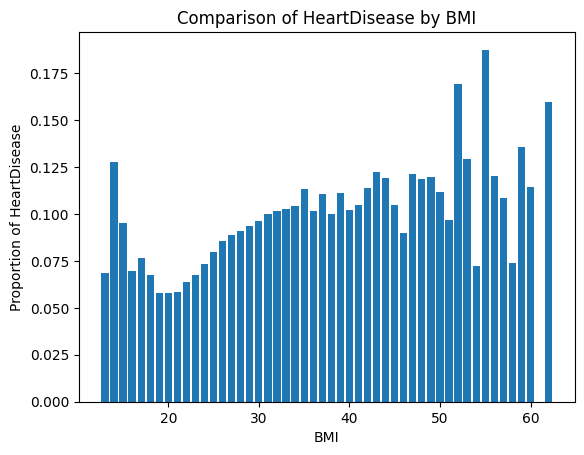

In [ ]:
bar_chart_comparison(data,"HeartDisease","BMI")


# DATA PREPROCESSING

DATA SAMPLING

In [ ]:
#load data
data_reload = pd.read_csv('/content/drive/MyDrive/Mission Capstone/Diagnosis/heart_2020_cleaned.csv')
data_reload.head(10)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No
6,No,21.63,No,No,No,15.0,0.0,No,Female,70-74,White,No,Yes,Fair,4.0,Yes,No,Yes
7,No,31.64,Yes,No,No,5.0,0.0,Yes,Female,80 or older,White,Yes,No,Good,9.0,Yes,No,No
8,No,26.45,No,No,No,0.0,0.0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5.0,No,Yes,No
9,No,40.69,No,No,No,0.0,0.0,Yes,Male,65-69,White,No,Yes,Good,10.0,No,No,No


In [ ]:
data_reload.shape
row, col = data_reload.shape
print(f"The DataFrame has {row} rows and {col} columns.")

The DataFrame has 319795 rows and 18 columns.


In [ ]:
# Print the range of each column
for col in data_reload.columns:
    print(f"Column: {col}")
    if pd.api.types.is_numeric_dtype(data_reload[col]):
        print(f"  Min: {data_reload[col].min()}, Max: {data_reload[col].max()}")
    else:
        print(f"  Unique values: {data_reload[col].unique()}")

Column: HeartDisease
  Unique values: ['No' 'Yes']
Column: BMI
  Min: 12.02, Max: 94.85
Column: Smoking
  Unique values: ['Yes' 'No']
Column: AlcoholDrinking
  Unique values: ['No' 'Yes']
Column: Stroke
  Unique values: ['No' 'Yes']
Column: PhysicalHealth
  Min: 0.0, Max: 30.0
Column: MentalHealth
  Min: 0.0, Max: 30.0
Column: DiffWalking
  Unique values: ['No' 'Yes']
Column: Sex
  Unique values: ['Female' 'Male']
Column: AgeCategory
  Unique values: ['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']
Column: Race
  Unique values: ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']
Column: Diabetic
  Unique values: ['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']
Column: PhysicalActivity
  Unique values: ['Yes' 'No']
Column: GenHealth
  Unique values: ['Very good' 'Fair' 'Good' 'Poor' 'Excellent']
Column: SleepTime
  Min: 1.0, Max: 24.0
Column: Asthma
  Unique values: ['Yes' 'No']
Col

Adding ECG_Classification, Diagnosis, CriticalAlert, Recommendation, FollowUp

In [ ]:
import random
import pandas as pd

# Define possible ECG classifications
ecg_classes = ['Myocardial Infarction', 'Normal Heartbeat', 'History of Myocardial Infarction', 'Abnormal Heartbeat']

# Diagnosis Function with Doctor's Notes
def assign_diagnosis(ecg_class, heart_disease):
    if ecg_class == 'Myocardial Infarction':
        if heart_disease == 'Yes':
            return 'Acute Coronary Syndrome with High Risk of Recurrence. Notes: This is a critical scenario with high urgency. Cardiac specialists may prioritize intervention and close follow-up.'
        else:
            return 'Previous Myocardial Infarction; Stable Condition. Notes: It’s rare but possible to see an ECG showing MI-like patterns without current heart disease. This could be due to past incidents or artifacts; further investigation is advised.'
    elif ecg_class == 'History of Myocardial Infarction':
        if heart_disease == 'Yes':
            return 'History of Myocardial Infarction; Risk of Complications. Notes: Patients with a history of MI who have ongoing heart disease may face complications, necessitating moderate follow-up and lifestyle management.'
        else:
            return 'Stable Post-MI; No Current Risk. Notes: This could be a case of a patient with a resolved MI and no active disease. Regular monitoring may suffice.'
    elif ecg_class == 'Abnormal Heartbeat':
        if heart_disease == 'Yes':
            return 'Chronic Arrhythmia. Notes: Chronic arrhythmia in a patient with heart disease typically requires close monitoring and aggressive management.'
        else:
            return 'Minor Arrhythmia; No Immediate Concern. Notes: This case could arise in patients with benign arrhythmias. Lifestyle changes are often effective here, with minimal intervention.'
    else:  # Normal Heartbeat
        if heart_disease == 'Yes':
            return 'Early Signs of Cardiac Risk. Notes: Doctors may suggest preventive cardiology as early heart disease risk factors might be present even with a normal ECG.'
        else:
            return 'Healthy Cardiac Status. Notes: This is a typical, low-risk case with no immediate need for intervention.'


# Recommendation Function with Critical Alert and Follow-Up
def assign_recommendation(diagnosis):
    recommendations = {
       'Acute Coronary Syndrome with High Risk of Recurrence. Notes: This is a critical scenario with high urgency. Cardiac specialists may prioritize intervention and close follow-up.': {
            'Recommendation': 'Immediate referral to a cardiologist, with prescriptions for anticoagulants and lifestyle changes.',
            'FollowUp': 'Weekly follow-up until the condition stabilizes.',
            'CriticalAlert': 'High',
            'Referral': 'Yes'
        },
        'Previous Myocardial Infarction; Stable Condition. Notes: It’s rare but possible to see an ECG showing MI-like patterns without current heart disease. This could be due to past incidents or artifacts; further investigation is advised.': {
            'Recommendation': 'Regular cardiovascular assessment every 3 months; monitor symptoms.',
            'FollowUp': '3-month follow-up with primary care.',
            'CriticalAlert': 'Medium',
            'Referral': 'Consider cardiology if symptoms worsen'
        },
       'History of Myocardial Infarction; Risk of Complications. Notes: Patients with a history of MI who have ongoing heart disease may face complications, necessitating moderate follow-up and lifestyle management.': {
            'Recommendation': 'Lifestyle counseling, adherence to medications, and low-dose aspirin.',
            'FollowUp': 'Monthly check-ins to assess risk.',
            'CriticalAlert': 'Medium',
            'Referral': 'Yes'
        },
       'Stable Post-MI; No Current Risk. Notes: This could be a case of a patient with a resolved MI and no active disease. Regular monitoring may suffice.': {
            'Recommendation': 'Annual cardiovascular exam and a healthy lifestyle.',
            'FollowUp': 'Annual check-up.',
            'CriticalAlert': 'Low',
            'Referral': 'No'
        },
        'Chronic Arrhythmia. Notes: Chronic arrhythmia in a patient with heart disease typically requires close monitoring and aggressive management.': {
            'Recommendation': 'Anti-arrhythmic drugs and possible ablation therapy; avoid strenuous activities.',
            'FollowUp': 'Bi-weekly follow-up with ECG monitoring.',
            'CriticalAlert': 'High',
            'Referral': 'Yes'
        },
        'Minor Arrhythmia; No Immediate Concern. Notes: This case could arise in patients with benign arrhythmias. Lifestyle changes are often effective here, with minimal intervention.': {
            'Recommendation': 'Lifestyle modifications, such as reducing caffeine and managing stress.',
            'FollowUp': '3-month follow-up if symptoms develop.',
            'CriticalAlert': 'Low',
            'Referral': 'No'
        },
        'Healthy Cardiac Status. Notes: This is a typical, low-risk case with no immediate need for intervention.'
: {
            'Recommendation': 'Maintain a balanced diet, regular exercise, and healthy sleep habits.',
            'FollowUp': 'Annual wellness check-up.',
            'CriticalAlert': 'Low',
            'Referral': 'No'
        },
        'Early Signs of Cardiac Risk. Notes: Doctors may suggest preventive cardiology as early heart disease risk factors might be present even with a normal ECG.': {
            'Recommendation': 'Begin preventive medication and a cardiovascular fitness plan.',
            'FollowUp': '6-month follow-up for early intervention.',
            'CriticalAlert': 'Medium',
            'Referral': 'Consider preventive cardiology'
        }
    }

    # Default recommendation for any diagnosis not in the dictionary
    default_response = {
        'Recommendation': 'General health advice.',
        'FollowUp': 'Annual check-up.',
        'CriticalAlert': 'Low',
        'Referral': 'No'
    }
    return recommendations.get(diagnosis, default_response)


# Apply functions to data
data_reload['ECG_Classification'] = [random.choice(ecg_classes) for _ in range(len(data_reload))]
data_reload['Diagnosis_And_Notes'] = data_reload.apply(lambda row: assign_diagnosis(row['ECG_Classification'], row['HeartDisease']), axis=1)

# Extract and expand recommendations into separate columns
data_reload[['Recommendation', 'FollowUp', 'CriticalAlert', 'Referral']] = data_reload['Diagnosis_And_Notes'].apply(
    lambda diagnosis: pd.Series(assign_recommendation(diagnosis))
)


In [ ]:
# Sample a few records to verify
print(data_reload[['ECG_Classification', 'HeartDisease', 'Diagnosis_And_Notes', 'Recommendation', 'FollowUp', 'CriticalAlert', 'Referral']].sample(5))


           ECG_Classification HeartDisease  \
275312       Normal Heartbeat           No   
286151  Myocardial Infarction           No   
292690     Abnormal Heartbeat           No   
10446        Normal Heartbeat           No   
118627       Normal Heartbeat           No   

                                      Diagnosis_And_Notes  \
275312  Healthy Cardiac Status. Notes: This is a typic...   
286151  Previous Myocardial Infarction; Stable Conditi...   
292690  Minor Arrhythmia; No Immediate Concern. Notes:...   
10446   Healthy Cardiac Status. Notes: This is a typic...   
118627  Healthy Cardiac Status. Notes: This is a typic...   

                                           Recommendation  \
275312  Maintain a balanced diet, regular exercise, an...   
286151  Regular cardiovascular assessment every 3 mont...   
292690  Lifestyle modifications, such as reducing caff...   
10446   Maintain a balanced diet, regular exercise, an...   
118627  Maintain a balanced diet, regular exercise,

In [ ]:
recommendations = data_reload['Recommendation'].unique()
recommendations

array(['Regular cardiovascular assessment every 3 months; monitor symptoms.',
       'Lifestyle modifications, such as reducing caffeine and managing stress.',
       'Immediate referral to a cardiologist, with prescriptions for anticoagulants and lifestyle changes.',
       'Maintain a balanced diet, regular exercise, and healthy sleep habits.',
       'Lifestyle counseling, adherence to medications, and low-dose aspirin.',
       'Annual cardiovascular exam and a healthy lifestyle.',
       'Begin preventive medication and a cardiovascular fitness plan.',
       'Anti-arrhythmic drugs and possible ablation therapy; avoid strenuous activities.'],
      dtype=object)

In [ ]:
# Save the DataFrame to a new CSV file
data_reload.to_csv('/content/drive/MyDrive/Mission Capstone/Diagnosis/updated_data_with_diagnosis.csv', index=False)


In [ ]:
working_data = pd.read_csv('/content/drive/MyDrive/Mission Capstone/Diagnosis/updated_data_with_diagnosis.csv')
working_data.head(10)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,SleepTime,Asthma,KidneyDisease,SkinCancer,ECG_Classification,Diagnosis_And_Notes,Recommendation,FollowUp,CriticalAlert,Referral
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,...,5.0,Yes,No,Yes,Myocardial Infarction,Previous Myocardial Infarction; Stable Conditi...,Regular cardiovascular assessment every 3 mont...,3-month follow-up with primary care.,Medium,Consider cardiology if symptoms worsen
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,...,7.0,No,No,No,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,...,8.0,Yes,No,No,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,...,6.0,No,No,Yes,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,...,8.0,No,No,No,Myocardial Infarction,Previous Myocardial Infarction; Stable Conditi...,Regular cardiovascular assessment every 3 mont...,3-month follow-up with primary care.,Medium,Consider cardiology if symptoms worsen
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,...,12.0,No,No,No,Myocardial Infarction,Acute Coronary Syndrome with High Risk of Recu...,"Immediate referral to a cardiologist, with pre...",Weekly follow-up until the condition stabilizes.,High,Yes
6,No,21.63,No,No,No,15.0,0.0,No,Female,70-74,...,4.0,Yes,No,Yes,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
7,No,31.64,Yes,No,No,5.0,0.0,Yes,Female,80 or older,...,9.0,Yes,No,No,Normal Heartbeat,Healthy Cardiac Status. Notes: This is a typic...,"Maintain a balanced diet, regular exercise, an...",Annual wellness check-up.,Low,No
8,No,26.45,No,No,No,0.0,0.0,No,Female,80 or older,...,5.0,No,Yes,No,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
9,No,40.69,No,No,No,0.0,0.0,Yes,Male,65-69,...,10.0,No,No,No,Normal Heartbeat,Healthy Cardiac Status. Notes: This is a typic...,"Maintain a balanced diet, regular exercise, an...",Annual wellness check-up.,Low,No


In [ ]:
working_data.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer', 'ECG_Classification',
       'Diagnosis_And_Notes', 'Recommendation', 'FollowUp', 'CriticalAlert',
       'Referral'],
      dtype='object')

In [ ]:
# Check for data types and missing values
print(working_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   HeartDisease         319795 non-null  object 
 1   BMI                  319795 non-null  float64
 2   Smoking              319795 non-null  object 
 3   AlcoholDrinking      319795 non-null  object 
 4   Stroke               319795 non-null  object 
 5   PhysicalHealth       319795 non-null  float64
 6   MentalHealth         319795 non-null  float64
 7   DiffWalking          319795 non-null  object 
 8   Sex                  319795 non-null  object 
 9   AgeCategory          319795 non-null  object 
 10  Race                 319795 non-null  object 
 11  Diabetic             319795 non-null  object 
 12  PhysicalActivity     319795 non-null  object 
 13  GenHealth            319795 non-null  object 
 14  SleepTime            319795 non-null  float64
 15  Asthma           

In [ ]:
# Sample the data
sampled_data = working_data.sample(n=30000, random_state=42)

# Save the sampled data to a CSV file
sampled_data.to_csv('/content/drive/MyDrive/Mission Capstone/Diagnosis/30k_sampled_data.csv', index=False)

In [ ]:
# Display the sampled data
sampled_data.head(10)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,SleepTime,Asthma,KidneyDisease,SkinCancer,ECG_Classification,Diagnosis_And_Notes,Recommendation,FollowUp,CriticalAlert,Referral
271884,No,27.63,Yes,No,No,0.0,25.0,No,Female,25-29,...,7.0,No,No,No,History of Myocardial Infarction,Stable Post-MI; No Current Risk. Notes: This c...,Annual cardiovascular exam and a healthy lifes...,Annual check-up.,Low,No
270361,No,21.95,No,No,No,0.0,20.0,No,Female,30-34,...,6.0,No,No,Yes,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
219060,No,31.32,Yes,No,No,0.0,0.0,No,Female,40-44,...,6.0,Yes,No,No,Myocardial Infarction,Previous Myocardial Infarction; Stable Conditi...,Regular cardiovascular assessment every 3 mont...,3-month follow-up with primary care.,Medium,Consider cardiology if symptoms worsen
24010,No,40.35,No,No,No,30.0,0.0,No,Female,65-69,...,8.0,No,No,No,Normal Heartbeat,Healthy Cardiac Status. Notes: This is a typic...,"Maintain a balanced diet, regular exercise, an...",Annual wellness check-up.,Low,No
181930,No,35.61,Yes,No,No,30.0,30.0,Yes,Female,60-64,...,4.0,Yes,No,Yes,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
24149,Yes,24.63,Yes,No,No,0.0,0.0,No,Female,80 or older,...,8.0,No,No,No,Abnormal Heartbeat,Chronic Arrhythmia. Notes: Chronic arrhythmia ...,Anti-arrhythmic drugs and possible ablation th...,Bi-weekly follow-up with ECG monitoring.,High,Yes
185683,No,41.73,No,No,No,0.0,0.0,No,Male,35-39,...,7.0,No,No,No,History of Myocardial Infarction,Stable Post-MI; No Current Risk. Notes: This c...,Annual cardiovascular exam and a healthy lifes...,Annual check-up.,Low,No
316656,No,16.30,No,No,No,2.0,0.0,No,Female,25-29,...,8.0,No,No,No,Myocardial Infarction,Previous Myocardial Infarction; Stable Conditi...,Regular cardiovascular assessment every 3 mont...,3-month follow-up with primary care.,Medium,Consider cardiology if symptoms worsen
305719,No,21.52,Yes,No,No,30.0,0.0,No,Male,65-69,...,8.0,No,No,No,Abnormal Heartbeat,Minor Arrhythmia; No Immediate Concern. Notes:...,"Lifestyle modifications, such as reducing caff...",3-month follow-up if symptoms develop.,Low,No
56786,No,29.53,Yes,No,No,28.0,30.0,Yes,Male,45-49,...,5.0,Yes,No,No,Myocardial Infarction,Previous Myocardial Infarction; Stable Conditi...,Regular cardiovascular assessment every 3 mont...,3-month follow-up with primary care.,Medium,Consider cardiology if symptoms worsen


In [ ]:
sampled_data.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer', 'ECG_Classification',
       'Diagnosis_And_Notes', 'Recommendation', 'FollowUp', 'CriticalAlert',
       'Referral'],
      dtype='object')

In [ ]:
sampled_data.shape

(30000, 24)

In [ ]:
# Check for NaN values in the entire DataFrame
print(sampled_data.isnull().sum())


HeartDisease           0
BMI                    0
Smoking                0
AlcoholDrinking        0
Stroke                 0
PhysicalHealth         0
MentalHealth           0
DiffWalking            0
Sex                    0
AgeCategory            0
Race                   0
Diabetic               0
PhysicalActivity       0
GenHealth              0
SleepTime              0
Asthma                 0
KidneyDisease          0
SkinCancer             0
ECG_Classification     0
Diagnosis_And_Notes    0
Recommendation         0
FollowUp               0
CriticalAlert          0
Referral               0
dtype: int64


# Preparing Data for Training

In [ ]:
# Import necessary libraries
import json
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import pickle  # For saving encoders and scalers

# Define columns based on feature type
col_binary = ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Diabetic',
              'Diagnosis_And_Notes', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer', 'HeartDisease']
col_categorical = ['AgeCategory', 'Race', 'GenHealth', 'ECG_Classification',
                   'Recommendation', 'FollowUp', 'Referral', 'CriticalAlert']
col_continuous = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

# Combine all categorical columns (binary and categorical)
all_categorical_cols = col_binary + col_categorical

# Initialize Label Encoders for Categorical Columns
original_labels = {}
label_encoders = {}
for col in all_categorical_cols:
    original_labels[col] = sampled_data[col].copy()  # Store a copy of the original column
    le = LabelEncoder()
    # Encode training set
    if col in sampled_data.columns:
        sampled_data[col] = le.fit_transform(sampled_data[col].astype(str))
    else:
        print(f"Column '{col}' not found in new_data DataFrame")
    # Save the encoder for each column
    label_encoders[col] = le

# Standardize Continuous Columns
scaler = StandardScaler()
sampled_data[col_continuous] = scaler.fit_transform(sampled_data[col_continuous])

# Save each encoder to a separate file
encoder_save_path = '/content/drive/MyDrive/Mission Capstone/Diagnosis/label_encoder/'
for col, le in label_encoders.items():
    with open(f"{encoder_save_path}{col}_encoder.pkl", "wb") as f:
        pickle.dump(le, f)

# Save the scaler
scaler_save_path = '/content/drive/MyDrive/Mission Capstone/Diagnosis/label_encoder/'
with open(f"{scaler_save_path}continuous_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Encoders and scaler saved successfully.")


Encoders and scaler saved successfully.


In [ ]:
#Mapping of encoded labels
for col in all_categorical_cols:
    print(f"Original Labels for {col}:")
    print(original_labels[col].unique())


    print(f"\nEncoded Labels for {col}:")
    print(sampled_data[col].unique())
    print("-" * 50)

Original Labels for Smoking:
['Yes' 'No']

Encoded Labels for Smoking:
[1 0]
--------------------------------------------------
Original Labels for AlcoholDrinking:
['No' 'Yes']

Encoded Labels for AlcoholDrinking:
[0 1]
--------------------------------------------------
Original Labels for Stroke:
['No' 'Yes']

Encoded Labels for Stroke:
[0 1]
--------------------------------------------------
Original Labels for DiffWalking:
['No' 'Yes']

Encoded Labels for DiffWalking:
[0 1]
--------------------------------------------------
Original Labels for Sex:
['Female' 'Male']

Encoded Labels for Sex:
[0 1]
--------------------------------------------------
Original Labels for Diabetic:
['No' 'Yes' 'No, borderline diabetes' 'Yes (during pregnancy)']

Encoded Labels for Diabetic:
[0 2 1 3]
--------------------------------------------------
Original Labels for Diagnosis_And_Notes:
['Stable Post-MI; No Current Risk. Notes: This could be a case of a patient with a resolved MI and no active diseas

In [ ]:
# Check for strings in the encoded labels
for col in all_categorical_cols:
    # Check if any encoded label is a string
    if any(isinstance(label, str) for label in sampled_data[col].unique()):
        print(f"Column '{col}' contains string encoded labels.")
        print(f"Unique values: {sampled_data[col].unique()}")
    else:
        print(f"Column '{col}' does not contain string encoded labels.")

Column 'Smoking' does not contain string encoded labels.
Column 'AlcoholDrinking' does not contain string encoded labels.
Column 'Stroke' does not contain string encoded labels.
Column 'DiffWalking' does not contain string encoded labels.
Column 'Sex' does not contain string encoded labels.
Column 'Diabetic' does not contain string encoded labels.
Column 'Diagnosis_And_Notes' does not contain string encoded labels.
Column 'PhysicalActivity' does not contain string encoded labels.
Column 'Asthma' does not contain string encoded labels.
Column 'KidneyDisease' does not contain string encoded labels.
Column 'SkinCancer' does not contain string encoded labels.
Column 'HeartDisease' does not contain string encoded labels.
Column 'AgeCategory' does not contain string encoded labels.
Column 'Race' does not contain string encoded labels.
Column 'GenHealth' does not contain string encoded labels.
Column 'ECG_Classification' does not contain string encoded labels.
Column 'Recommendation' does not

In [ ]:
sampled_data.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,SleepTime,Asthma,KidneyDisease,SkinCancer,ECG_Classification,Diagnosis_And_Notes,Recommendation,FollowUp,CriticalAlert,Referral
271884,0,-0.113953,1,0,0,-0.430753,2.653652,0,0,1,...,-0.078047,0,0,0,1,7,0,3,1,2
270361,0,-1.004702,0,0,0,-0.430753,2.025003,0,0,2,...,-0.773447,0,0,1,0,5,5,0,1,2
219060,0,0.464720,1,0,0,-0.430753,-0.489592,0,0,4,...,-0.773447,1,0,0,2,6,7,1,2,0
24010,0,1.880822,0,0,0,3.295055,-0.489592,0,0,9,...,0.617353,0,0,0,3,3,6,4,1,2
181930,0,1.137486,1,0,0,3.295055,3.282301,1,0,8,...,-2.164248,1,0,1,0,5,5,0,1,2


In [ ]:
# Extract the relevant columns
diagnosis_data = sampled_data[['ECG_Classification', 'Diagnosis_And_Notes','HeartDisease', 'Recommendation', 'CriticalAlert', 'FollowUp', 'Referral']]

# Display the new DataFrame
diagnosis_data.head()


,ECG_Classification,Diagnosis_And_Notes,HeartDisease,Recommendation,CriticalAlert,FollowUp,Referral
271884,1,7,0,0,1,3,2
270361,0,5,0,5,1,0,2
219060,2,6,0,7,2,1,0
24010,3,3,0,6,1,4,2
181930,0,5,0,5,1,0,2


# **Section 3: Model Implementation**

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import json
import os


# Stage 1: Feature extraction from sampled_data
X_stage1 = sampled_data[['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth',
                         'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
                         'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']]

# Stage 2: Feature extraction from new_data
X_stage2 = diagnosis_data[['ECG_Classification']]  # ECG_Classification as input for stage 2
y_heart_disease = diagnosis_data['HeartDisease']  # HeartDisease target for Stage 1
y_stage2 = diagnosis_data[['Diagnosis_And_Notes','Recommendation', 'CriticalAlert', 'FollowUp', 'Referral']]  # Targets for Stage 2

# Scale the features (e.g., for Stage 1)
scaler = StandardScaler()

# Scale the data for Stage 1
X_stage1_scaled = scaler.fit_transform(X_stage1)

# Split the data into training and testing sets for both stages
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X_stage1_scaled, y_heart_disease, test_size=0.2, random_state=42)

X_train_stage2, X_test_stage2, y_train_stage2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42)

# Number of unique classes for Stage 2
num_diagnosis_classes = len(y_stage2['Diagnosis_And_Notes'].unique())
num_recommendation_classes = len(y_stage2['Recommendation'].unique())
num_critical_alert_classes = len(y_stage2['CriticalAlert'].unique())
num_follow_up_classes = len(y_stage2['FollowUp'].unique())
num_referral_classes = len(y_stage2['Referral'].unique())

# Input layer for Stage 1 (HeartDisease prediction)
input_stage1 = tf.keras.layers.Input(shape=(X_train_stage1.shape[1],))

# Stage 1: HeartDisease prediction
x_stage1 = tf.keras.layers.Dense(64, activation="relu")(input_stage1)
x_stage1 = tf.keras.layers.Dropout(0.3)(x_stage1)
x_stage1 = tf.keras.layers.Dense(32, activation="relu")(x_stage1)
heart_disease_output = tf.keras.layers.Dense(1, activation="sigmoid", name="heart_disease")(x_stage1)

# Input layer for Stage 2 (ECG Classification input)
input_ecg = tf.keras.layers.Input(shape=(X_train_stage2.shape[1],))

# Combine HeartDisease prediction with ECG_Classification for Stage 2 input
combined_stage2_input = tf.keras.layers.Concatenate()([heart_disease_output, input_ecg])

# Stage 2: Secondary predictions (Recommendation, CriticalAlert, FollowUp, Referral)
x_stage2 = tf.keras.layers.Dense(64, activation="relu")(combined_stage2_input)
x_stage2 = tf.keras.layers.Dropout(0.3)(x_stage2)
x_stage2 = tf.keras.layers.Dense(32, activation="relu")(x_stage2)

# Output layers for each target in Stage 2
diagnosis_output = tf.keras.layers.Dense(num_diagnosis_classes, activation="softmax", name="diagnosis")(x_stage2)
recommendation_output = tf.keras.layers.Dense(num_recommendation_classes, activation="softmax", name="recommendation")(x_stage2)
critical_alert_output = tf.keras.layers.Dense(num_critical_alert_classes, activation="softmax", name="critical_alert")(x_stage2)
follow_up_output = tf.keras.layers.Dense(num_follow_up_classes, activation="softmax", name="follow_up")(x_stage2)
referral_output = tf.keras.layers.Dense(num_referral_classes, activation="softmax", name="referral")(x_stage2)

# Build the combined model
model = tf.keras.Model(inputs=[input_stage1, input_ecg], outputs=[ diagnosis_output,
    heart_disease_output, recommendation_output, critical_alert_output, follow_up_output, referral_output
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss={
                  "heart_disease": "binary_crossentropy",  # Binary classification for heart disease
                  "diagnosis": "sparse_categorical_crossentropy",  # Multi-class classification for recommendation
                  "recommendation": "sparse_categorical_crossentropy",  # Multi-class classification for recommendation
                  "critical_alert": "sparse_categorical_crossentropy",  # Multi-class classification for critical alert
                  "follow_up": "sparse_categorical_crossentropy",  # Multi-class classification for follow-up
                  "referral": "sparse_categorical_crossentropy"  # Multi-class classification for referral
              },
              metrics={
                  "heart_disease": ["accuracy"],
                  "diagnosis": ["accuracy"],
                  "heart_disease": ["accuracy"],
                  "recommendation": ["accuracy"],
                  "critical_alert": ["accuracy"],
                  "follow_up": ["accuracy"],
                  "referral": ["accuracy"]
              })

# Train the model
history = model.fit(
    [X_train_stage1, X_train_stage2],  # Inputs for both stages
    {
        "heart_disease": y_train_stage1,  # Stage 1 target
        "diagnosis": y_train_stage2['Diagnosis_And_Notes'],
        "recommendation": y_train_stage2['Recommendation'],
        "critical_alert": y_train_stage2['CriticalAlert'],
        "follow_up": y_train_stage2['FollowUp'],
        "referral": y_train_stage2['Referral']
    },
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

# Save the model and training history
save_path_model = '/content/drive/MyDrive/Mission Capstone/Diagnosis/Model/first_combined_heart_model.h5'
model.save(save_path_model)

save_path_history = '/content/drive/MyDrive/Mission Capstone/Diagnosis/ModelHistory/first_combined_model_history.json'
os.makedirs(os.path.dirname(save_path_history), exist_ok=True)
with open(save_path_history, "w") as f:
    json.dump(history.history, f)


Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - critical_alert_accuracy: 0.7050 - diagnosis_accuracy: 0.5651 - follow_up_accuracy: 0.5967 - heart_disease_accuracy: 0.8715 - loss: 5.8201 - recommendation_accuracy: 0.6089 - referral_accuracy: 0.6889 - val_critical_alert_accuracy: 0.9137 - val_diagnosis_accuracy: 0.9137 - val_follow_up_accuracy: 0.9137 - val_heart_disease_accuracy: 0.9137 - val_loss: 2.0388 - val_recommendation_accuracy: 0.9137 - val_referral_accuracy: 0.9137
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - critical_alert_accuracy: 0.9104 - diagnosis_accuracy: 0.9103 - follow_up_accuracy: 0.9095 - heart_disease_accuracy: 0.9113 - loss: 2.1058 - recommendation_accuracy: 0.9100 - referral_accuracy: 0.9099 - val_critical_alert_accuracy: 0.9137 - val_diagnosis_accuracy: 0.9137 - val_follow_up_accuracy: 0.9137 - val_heart_disease_accuracy: 0.9137 - val_loss: 1.7990 - val_recommendation_accuracy: 0.9137 - val_referral_accuracy: 0.9137
Epoch 3/50
600/600 ━━━━━━━━━━━━━

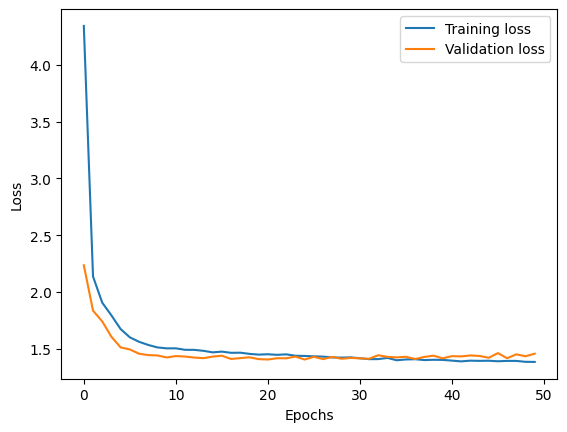

In [ ]:
# Load the history
with open("/content/drive/MyDrive/Mission Capstone/Diagnosis/ModelHistory/first_combined_model_history.json", "r") as f:
    saved_history = json.load(f)

# For example, plot the training and validation accuracy
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(saved_history['loss'], label='Training loss')
plt.plot(saved_history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Model with Regularization (L2 Regularization)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 17)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │          2,304 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 128)            │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 64)             │          8,256 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 64)             │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 32)             │          2,080 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease (Dense)     │ (None, 1)              │             33 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 2)              │              0 │ heart_disease[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 128)            │            384 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 128)            │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 64)             │          8,256 │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 64)             │              0 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 32)             │          2,080 │ dropout_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ diagnosis_and_notes       │ (None, 8)              │            264 │ dense_9[0][0]          │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ recommendation (Dense)    │ (None, 8)              │            264 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ critical_alert (Dense)    │ (None, 3)              │             99 │ dense_9[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ follow_up (Dense)    

 Total params: 24,416 (95.38 KB)

 Trainable params: 24,416 (95.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - critical_alert_accuracy: 0.6155 - diagnosis_and_notes_accuracy: 0.4758 - follow_up_accuracy: 0.4043 - heart_disease_accuracy: 0.8703 - loss: 8.4671 - recommendation_accuracy: 0.3987 - referral_accuracy: 0.6222 - val_critical_alert_accuracy: 0.9063 - val_diagnosis_and_notes_accuracy: 0.9063 - val_follow_up_accuracy: 0.9063 - val_heart_disease_accuracy: 0.9063 - val_loss: 3.3708 - val_recommendation_accuracy: 0.9063 - val_referral_accuracy: 0.9063
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - critical_alert_accuracy: 0.8920 - diagnosis_and_notes_accuracy: 0.8870 - follow_up_accuracy: 0.8915 - heart_disease_accuracy: 0.9124 - loss: 3.3413 - recommendation_accuracy: 0.8919 - referral_accuracy: 0.8953 - val_critical_alert_accuracy: 0.9063 - val_diagnosis_and_notes_accuracy: 0.9063 - val_follow_up_accuracy: 0.9063 - val_heart_disease_accuracy: 0.9063 - val_loss: 2.5342 - val_recommendation_accuracy: 0.9063 - val_referral_accuracy:

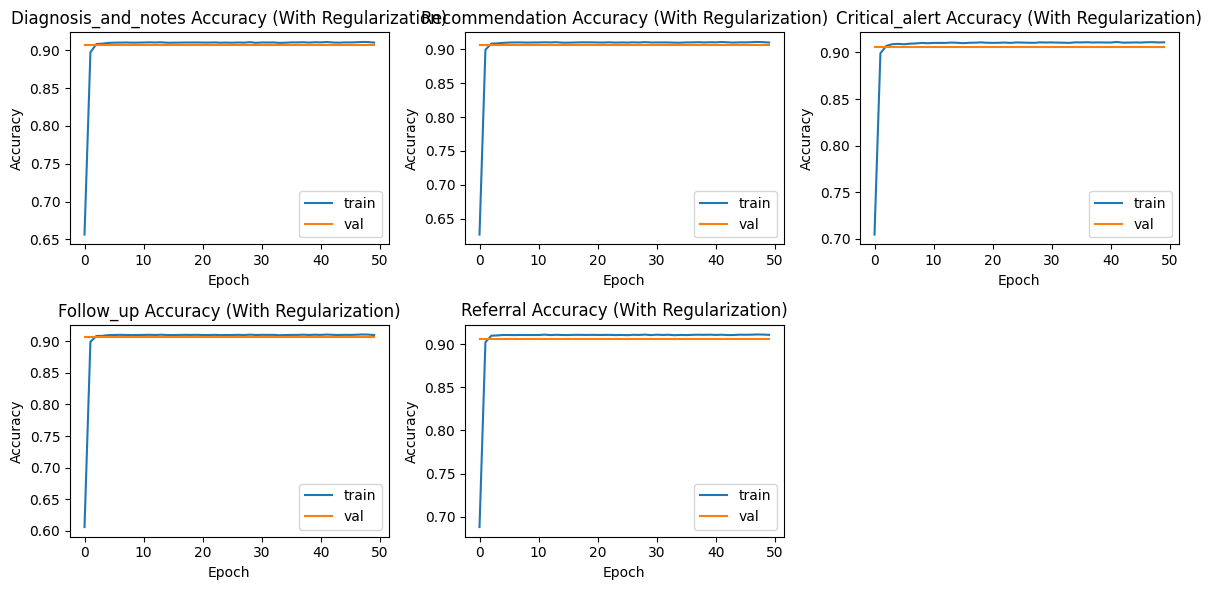

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
import os
import json
import matplotlib.pyplot as plt

# Split the data into features and targets for each stage
X_stage1 = sampled_data[['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth',
                         'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
                         'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']]

X_stage2 = sampled_data[['ECG_Classification']]  # ECG classification as input for stage 2

# Targets for each stage
y_heart_disease = sampled_data['HeartDisease']  # Target for Stage 1
y_stage2 = sampled_data[['Diagnosis_And_Notes', 'Recommendation', 'CriticalAlert', 'FollowUp', 'Referral']]

# Split the data into training and testing sets
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X_stage1, y_heart_disease, test_size=0.2, random_state=42)

X_train_stage2, X_test_stage2, y_train_stage2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42)


# Determine the number of unique classes for each target in Stage 2
num_diagnosis_classes = len(y_stage2['Diagnosis_And_Notes'].unique())
num_recommendation_classes = len(y_stage2['Recommendation'].unique())
num_critical_alert_classes = len(y_stage2['CriticalAlert'].unique())
num_follow_up_classes = len(y_stage2['FollowUp'].unique())
num_referral_classes = len(y_stage2['Referral'].unique())

# Input layers for both stages
input_stage1 = tf.keras.layers.Input(shape=(X_train_stage1.shape[1],))
input_stage2 = tf.keras.layers.Input(shape=(X_train_stage2.shape[1],))

# Stage 1: HeartDisease prediction
x_stage1 = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(0.01))(input_stage1)
x_stage1 = tf.keras.layers.Dropout(0.5)(x_stage1)
x_stage1 = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(0.01))(x_stage1)
x_stage1 = tf.keras.layers.Dropout(0.5)(x_stage1)
x_stage1 = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=l2(0.01))(x_stage1)
heart_disease_output = tf.keras.layers.Dense(1, activation="sigmoid", name="heart_disease")(x_stage1)

# Combine HeartDisease prediction with ECG_Classification for Stage 2 input
combined_input_stage2 = tf.keras.layers.Concatenate()([heart_disease_output, input_stage2])

# Stage 2: Shared hidden layers
x_stage2 = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(0.01))(combined_input_stage2)
x_stage2 = tf.keras.layers.Dropout(0.5)(x_stage2)
x_stage2 = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(0.01))(x_stage2)
x_stage2 = tf.keras.layers.Dropout(0.5)(x_stage2)
x_stage2 = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=l2(0.01))(x_stage2)

# Output layers for each target in Stage 2
diagnosis_output = tf.keras.layers.Dense(num_diagnosis_classes, activation="softmax", name="diagnosis_and_notes")(x_stage2)
recommendation_output = tf.keras.layers.Dense(num_recommendation_classes, activation="softmax", name="recommendation")(x_stage2)
critical_alert_output = tf.keras.layers.Dense(num_critical_alert_classes, activation="softmax", name="critical_alert")(x_stage2) # Changed to softmax and num_critical_alert_classes
follow_up_output = tf.keras.layers.Dense(num_follow_up_classes, activation="softmax", name="follow_up")(x_stage2)  # Changed to softmax and num_follow_up_classes
referral_output = tf.keras.layers.Dense(num_referral_classes, activation="softmax", name="referral")(x_stage2)  # Changed to softmax and num_referral_classes

# Build the combined model
model = tf.keras.Model(inputs=[input_stage1, input_stage2], outputs=[ # Changed input_ecg to input_stage2
    heart_disease_output, diagnosis_output, recommendation_output, critical_alert_output, follow_up_output, referral_output
])


# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss={
                  "heart_disease": "binary_crossentropy",
                  "diagnosis_and_notes": "sparse_categorical_crossentropy",
                  "recommendation": "sparse_categorical_crossentropy",
                  "critical_alert": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
                  "follow_up": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
                  "referral": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
              },
              metrics={
                "heart_disease": ["accuracy"],
                "diagnosis_and_notes": ["accuracy"],
                "recommendation": ["accuracy"],
                "critical_alert": ["accuracy"],
                "follow_up": ["accuracy"],
                "referral": ["accuracy"]
             })


# Print model summary
model.summary()

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(
    [X_train_stage1, X_train_stage2],
    [y_train_stage1, y_train_stage2['Diagnosis_And_Notes'], y_train_stage2['Recommendation'],
     y_train_stage2['CriticalAlert'], y_train_stage2['FollowUp'], y_train_stage2['Referral']],
    validation_data=([X_test_stage1, X_test_stage2],
                     [y_test_stage1, y_test_stage2['Diagnosis_And_Notes'], y_test_stage2['Recommendation'],
                      y_test_stage2['CriticalAlert'], y_test_stage2['FollowUp'], y_test_stage2['Referral']]),
    epochs=50,
    callbacks=[early_stopping]
)

# Save the model to Google Drive
save_path = '/content/drive/MyDrive/Mission Capstone/Diagnosis/Model/combined_heart_model_with_regularization.h5'
model.save(save_path)

# Save training history
save_path_history = '/content/drive/MyDrive/Mission Capstone/Diagnosis/ModelHistory/combined_model_history_with_regularization.json'
os.makedirs(os.path.dirname(save_path_history), exist_ok=True)
with open(save_path_history, "w") as f:
    json.dump(history.history, f)

# Plot training history
plt.figure(figsize=(12, 6))
for i, metric in enumerate(["diagnosis_and_notes", "recommendation", "critical_alert", "follow_up", "referral"]):
    plt.subplot(2, 3, i+1)
    plt.plot(history.history[f"{metric}_accuracy"], label='train')
    plt.plot(history.history[f"val_{metric}_accuracy"], label='val')
    plt.title(f'{metric.capitalize()} Accuracy (With Regularization)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
plt.tight_layout()
plt.show()


With Optimization

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 17)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 128)            │          2,304 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 128)            │              0 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 64)             │          8,256 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 64)             │              0 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 32)             │          2,080 │ dropout_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ heart_disease (Dense)     │ (None, 1)              │             33 │ dense_12[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 2)              │              0 │ heart_disease[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 128)            │            384 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 128)            │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 64)             │          8,256 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 64)             │              0 │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 32)             │          2,080 │ dropout_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ diagnosis_and_notes       │ (None, 8)              │            264 │ dense_15[0][0]         │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ recommendation (Dense)    │ (None, 8)              │            264 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ critical_alert (Dense)    │ (None, 3)              │             99 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ follow_up (Dense)    

 Total params: 24,416 (95.38 KB)

 Trainable params: 24,416 (95.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - critical_alert_accuracy: 0.6281 - diagnosis_and_notes_accuracy: 0.4260 - follow_up_accuracy: 0.3642 - heart_disease_accuracy: 0.8279 - loss: 6.8819 - recommendation_accuracy: 0.3563 - referral_accuracy: 0.6116 - val_critical_alert_accuracy: 0.9063 - val_diagnosis_and_notes_accuracy: 0.9063 - val_follow_up_accuracy: 0.9063 - val_heart_disease_accuracy: 0.9063 - val_loss: 2.5352 - val_recommendation_accuracy: 0.9063 - val_referral_accuracy: 0.9063
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - critical_alert_accuracy: 0.8859 - diagnosis_and_notes_accuracy: 0.8854 - follow_up_accuracy: 0.8857 - heart_disease_accuracy: 0.9118 - loss: 2.6150 - recommendation_accuracy: 0.8854 - referral_accuracy: 0.8742 - val_critical_alert_accuracy: 0.9063 - val_diagnosis_and_notes_accuracy: 0.9063 - val_follow_up_accuracy: 0.9063 - val_heart_disease_accuracy: 0.9063 - val_loss: 1.8814 - val_recommendation_accuracy: 0.9063 - val_referral_accuracy:

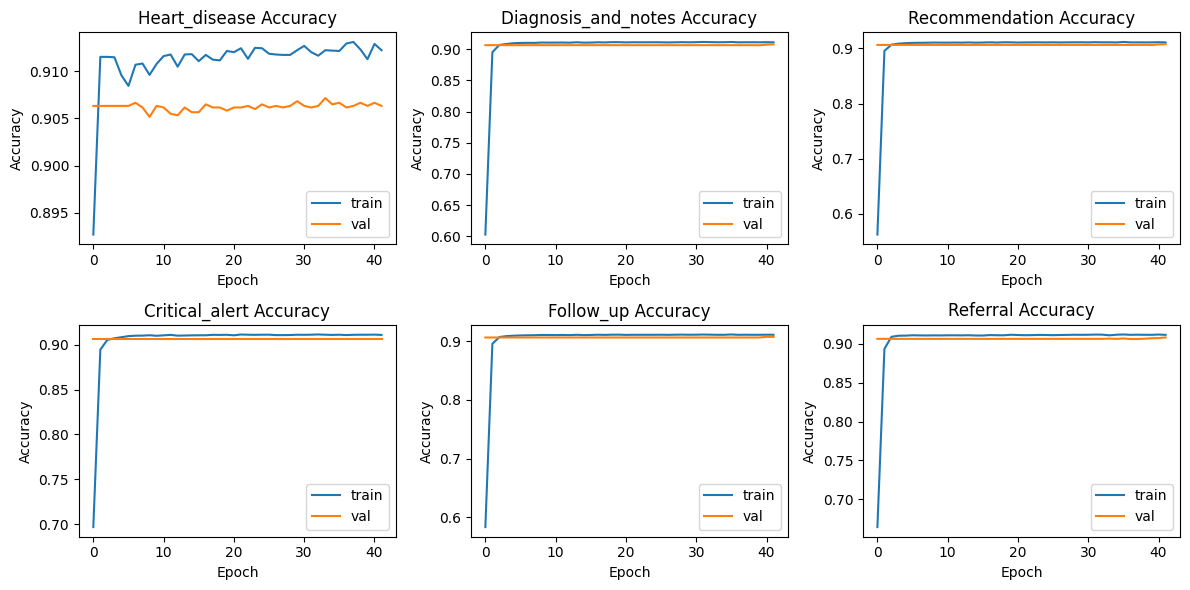

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import json
import os

# Split the data into features and targets for each stage
X_stage1 = sampled_data[['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth',
                         'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
                         'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']]

X_stage2 = sampled_data[['ECG_Classification']]  # ECG classification as input for stage 2

# Targets for each stage
y_heart_disease = sampled_data['HeartDisease']  # Target for Stage 1
y_stage2 = sampled_data[['Diagnosis_And_Notes', 'Recommendation', 'CriticalAlert', 'FollowUp', 'Referral']]

# Split the data into training and testing sets
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X_stage1, y_heart_disease, test_size=0.2, random_state=42)

X_train_stage2, X_test_stage2, y_train_stage2, y_test_stage2 = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42)


# Determine the number of unique classes for each target in Stage 2
num_diagnosis_classes = len(y_stage2['Diagnosis_And_Notes'].unique())
num_recommendation_classes = len(y_stage2['Recommendation'].unique())
num_critical_alert_classes = len(y_stage2['CriticalAlert'].unique())
num_follow_up_classes = len(y_stage2['FollowUp'].unique())
num_referral_classes = len(y_stage2['Referral'].unique())

# Input layer for Stage 1 (heart disease prediction)
input_stage1 = tf.keras.layers.Input(shape=(X_train_stage1.shape[1],))

# Stage 1: HeartDisease prediction
x_stage1 = tf.keras.layers.Dense(128, activation="relu")(input_stage1)
x_stage1 = tf.keras.layers.Dropout(0.5)(x_stage1)
x_stage1 = tf.keras.layers.Dense(64, activation="relu")(x_stage1)
x_stage1 = tf.keras.layers.Dropout(0.5)(x_stage1)
x_stage1 = tf.keras.layers.Dense(32, activation="relu")(x_stage1)
heart_disease_output = tf.keras.layers.Dense(1, activation="sigmoid", name="heart_disease")(x_stage1)

# Combine the HeartDisease prediction with the ECG_Classification feature for Stage 2 input
input_ecg = tf.keras.layers.Input(shape=(X_train_stage2.shape[1],))
combined_stage2_input = tf.keras.layers.Concatenate()([heart_disease_output, input_ecg])

# Stage 2: Prediction for Diagnosis, Recommendation, CriticalAlert, FollowUp, and Referral
x_stage2 = tf.keras.layers.Dense(128, activation="relu")(combined_stage2_input)
x_stage2 = tf.keras.layers.Dropout(0.5)(x_stage2)
x_stage2 = tf.keras.layers.Dense(64, activation="relu")(x_stage2)
x_stage2 = tf.keras.layers.Dropout(0.5)(x_stage2)
x_stage2 = tf.keras.layers.Dense(32, activation="relu")(x_stage2)

# Output layers for each target in Stage 2
diagnosis_and_notes_output = tf.keras.layers.Dense(num_diagnosis_classes, activation="softmax", name="diagnosis_and_notes")(x_stage2)
recommendation_output = tf.keras.layers.Dense(num_recommendation_classes, activation="softmax", name="recommendation")(x_stage2)
critical_alert_output = tf.keras.layers.Dense(num_critical_alert_classes, activation="softmax", name="critical_alert")(x_stage2) # Changed to softmax and num_critical_alert_classes
follow_up_output = tf.keras.layers.Dense(num_follow_up_classes, activation="softmax", name="follow_up")(x_stage2)  # Changed to softmax and num_follow_up_classes
referral_output = tf.keras.layers.Dense(num_referral_classes, activation="softmax", name="referral")(x_stage2)  # Changed to softmax and num_referral_classes

# Build the model
model = tf.keras.Model(inputs=[input_stage1, input_ecg], outputs=[
    heart_disease_output, diagnosis_and_notes_output, recommendation_output, critical_alert_output, follow_up_output, referral_output
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss={
                  "heart_disease": "binary_crossentropy",
                  "diagnosis_and_notes": "sparse_categorical_crossentropy",
                  "recommendation": "sparse_categorical_crossentropy",
                  "critical_alert": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
                  "follow_up": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
                  "referral": "sparse_categorical_crossentropy",  # Changed to sparse_categorical_crossentropy
              },
              metrics={
                "heart_disease": ["accuracy"],
                "diagnosis_and_notes": ["accuracy"],
                "recommendation": ["accuracy"],
                "critical_alert": ["accuracy"],
                "follow_up": ["accuracy"],
                "referral": ["accuracy"]
             })

# Print model summary
model.summary()

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(
    [X_train_stage1, X_train_stage2],
    [y_train_stage1, y_train_stage2['Diagnosis_And_Notes'], y_train_stage2['Recommendation'],
     y_train_stage2['CriticalAlert'], y_train_stage2['FollowUp'], y_train_stage2['Referral']],
    validation_data=([X_test_stage1, X_test_stage2],
                     [y_test_stage1, y_test_stage2['Diagnosis_And_Notes'], y_test_stage2['Recommendation'],
                      y_test_stage2['CriticalAlert'], y_test_stage2['FollowUp'], y_test_stage2['Referral']]),
    epochs=50,
    callbacks=[early_stopping]
)

#  Plot training history
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
for i, metric in enumerate(["heart_disease", "diagnosis_and_notes", "recommendation", "critical_alert", "follow_up", "referral"]):
    plt.subplot(2, 3, i+1)
    plt.plot(history.history[f"{metric}_accuracy"], label='train')
    plt.plot(history.history[f"val_{metric}_accuracy"], label='val')
    plt.title(f'{metric.capitalize()} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
plt.tight_layout()
plt.show()

# Save the model to Google Drive
save_path = '/content/drive/MyDrive/Mission Capstone/Diagnosis/Model/combined_optimized_model.h5'
model.save(save_path)

save_path_history = '/content/drive/MyDrive/Mission Capstone/Diagnosis/ModelHistory/combined_optimized_model_history.json'
os.makedirs(os.path.dirname(save_path_history), exist_ok=True)
with open(save_path_history, "w") as f:
    json.dump(history.history, f)


# TESTING MODEL

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os
import pickle
import pandas as pd

# Dictionary mappings for each feature
label_mappings = {
    'HeartDisease': {0: 'No', 1: 'Yes'},
    'Diagnosis_And_Notes': {
        0: 'Acute Coronary Syndrome with High Risk of Recurrence. Notes: This is a critical scenario with high urgency...',
        5: 'Minor Arrhythmia; No Immediate Concern. Notes: This case could arise in patients with benign arrhythmias...',
        3: 'Healthy Cardiac Status. Notes: This is a typical, low-risk case with no immediate need for intervention.',
        7: 'Stable Post-MI; No Current Risk. Notes: This could be a case of a patient with a resolved MI...',
        1: 'Chronic Arrhythmia. Notes: Chronic arrhythmia in a patient with heart disease typically requires...',
        6: 'Previous Myocardial Infarction; Stable Condition. Notes: It’s rare but possible to see an ECG showing MI...',
        4: 'History of Myocardial Infarction; Risk of Complications. Notes: Patients with a history of MI...',
        2: 'Early Signs of Cardiac Risk. Notes: Doctors may suggest preventive cardiology as early heart disease...'
    },
    'ECG_Classification': {0: 'Abnormal Heartbeat', 1: 'History of Myocardial Infarction', 2: 'Myocardial Infarction', 3: 'Normal Heartbeat'},
    'Recommendation': {
        0: 'Annual cardiovascular exam and a healthy lifestyle.',
        5: 'Lifestyle modifications, such as reducing caffeine and managing stress.',
        7: 'Regular cardiovascular assessment every 3 months; monitor symptoms.',
        6: 'Maintain a balanced diet, regular exercise, and healthy sleep habits.',
        1: 'Anti-arrhythmic drugs and possible ablation therapy; avoid strenuous activities.',
        3: 'Immediate referral to a cardiologist, with prescriptions for anticoagulants and lifestyle changes.',
        4: 'Lifestyle counseling, adherence to medications, and low-dose aspirin.',
        2: 'Begin preventive medication and a cardiovascular fitness plan.'
    },
    'FollowUp': {
        3: 'Annual check-up.',
        0: '3-month follow-up if symptoms develop.',
        1: '3-month follow-up with primary care.',
        4: 'Annual wellness check-up.',
        5: 'Bi-weekly follow-up with ECG monitoring.',
        7: 'Weekly follow-up until the condition stabilizes.',
        6: 'Monthly check-ins to assess risk.',
        2: '6-month follow-up for early intervention.'
    },
    'Referral': {0: 'Consider cardiology if symptoms worsen', 1: 'Consider preventive cardiology', 2: 'No', 3: 'Yes'},
    'CriticalAlert': {0: 'High', 1: 'Low', 2: 'Medium'}
}

# Function to map encoded predictions to original labels using the dictionaries
def map_encoded_to_original(encoded_predictions):
    mapped_predictions = {}

    for feature, encoded_value in encoded_predictions.items():
        # Get the dictionary for each feature from the label_mappings
        feature_mapping = label_mappings.get(feature)

        if feature_mapping:
            # Map the encoded value to the original label
            mapped_predictions[feature] = feature_mapping.get(encoded_value[0], 'Unknown')

    return mapped_predictions


# Import necessary libraries for model prediction
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import pickle
import os

# Load saved encoders and scaler from the drive
encoders_path = "/content/drive/MyDrive/Mission Capstone/Diagnosis/label_encoder/"
scaler_path = "/content/drive/MyDrive/Mission Capstone/Diagnosis/label_encoder/continuous_scaler.pkl"

# Load individual label encoders
def load_encoder(file_name):
    with open(os.path.join(encoders_path, file_name), "rb") as f:
        return pickle.load(f)

# Load all encoders
encoders = {
    'HeartDisease': load_encoder("HeartDisease_label_encoder.pkl"),
    'Diagnosis': load_encoder("Diagnosis_And_Notes_label_encoder.pkl"),
    'Recommendation': load_encoder("Recommendation_label_encoder.pkl"),
    'CriticalAlert': load_encoder("CriticalAlert_label_encoder.pkl"),
    'FollowUp': load_encoder("FollowUp_label_encoder.pkl"),
    'Referral': load_encoder("Referral_label_encoder.pkl"),
    'ECG_Classification': load_encoder("ECG_Classification_label_encoder.pkl"),
    'Smoking': load_encoder("Smoking_label_encoder.pkl"),
    'AlcoholDrinking': load_encoder("AlcoholDrinking_label_encoder.pkl"),
    'Stroke': load_encoder("Stroke_label_encoder.pkl"),
    'DiffWalking': load_encoder("DiffWalking_label_encoder.pkl"),
    'Sex': load_encoder("Sex_label_encoder.pkl"),
    'AgeCategory': load_encoder("AgeCategory_label_encoder.pkl"),
    'Race': load_encoder("Race_label_encoder.pkl"),
    'Diabetic': load_encoder("Diabetic_label_encoder.pkl"),
    'PhysicalActivity': load_encoder("PhysicalActivity_label_encoder.pkl"),
    'GenHealth': load_encoder("GenHealth_label_encoder.pkl"),
    'Asthma': load_encoder("Asthma_label_encoder.pkl"),
    'KidneyDisease': load_encoder("KidneyDisease_label_encoder.pkl"),
    'SkinCancer': load_encoder("SkinCancer_label_encoder.pkl")
}

# Load the scaler for continuous columns
with open(scaler_path, "rb") as f:
    continuous_scaler = pickle.load(f)

# Continuous columns
col_continuous = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

# Function to apply encoding to categorical features
def apply_encoding(data, encoders):
    for feature, encoder in encoders.items():
        if feature in data.columns:
            try:
                data[feature] = encoder.transform(data[feature])
            except ValueError:
                # Handle unseen labels by replacing with the first known label
                known_classes = encoder.classes_
                data[feature] = data[feature].apply(lambda x: x if x in known_classes else known_classes[0])
                data[feature] = encoder.transform(data[feature])
    return data

# Prediction function
def predict(model, input_data):
    """
    This function takes input data, applies label encoding and scaling,
    and makes a prediction using the trained model.
    """
    # Convert input_data to DataFrame for easier processing
    input_df = pd.DataFrame(input_data)

    # Apply encoding to categorical features
    input_df = apply_encoding(input_df, encoders)

    # Scale continuous columns
    input_df[col_continuous] = continuous_scaler.transform(input_df[col_continuous])

    # Prepare data for model prediction
    heart_disease_data = input_df.drop(columns=['ECG_Classification'])
    ecg_classification_data = input_df[['ECG_Classification']]

    # Make predictions
    heart_disease_pred, diagnosis_pred, recommendation_pred, critical_alert_pred, follow_up_pred, referral_pred = model.predict(
        [heart_disease_data, ecg_classification_data]
    )

    # Collect encoded predictions
    encoded_predictions = {
        'HeartDisease': (heart_disease_pred.flatten() > 0.5).astype(int),
        'Diagnosis_And_Notes': np.argmax(diagnosis_pred, axis=1),
        'Recommendation': np.argmax(recommendation_pred, axis=1),
        'CriticalAlert': np.argmax(critical_alert_pred, axis=1),
        'FollowUp': np.argmax(follow_up_pred, axis=1),
        'Referral': np.argmax(referral_pred, axis=1)
    }

    # Map encoded predictions to original labels
    mapped_predictions = map_encoded_to_original(encoded_predictions)

    return mapped_predictions




# Load the trained model
model_path = '/content/drive/MyDrive/Mission Capstone/Diagnosis/Model/first_combined_heart_model.h5'
model = load_model(model_path)

# Example input data (replace with actual data)
input_data = {
    'BMI': [22.5],
    'Smoking': ['No'],
    'AlcoholDrinking': ['No'],
    'Stroke': ['No'],
    'PhysicalHealth': [80],
    'MentalHealth': [75],
    'DiffWalking': ['Yes'],
    'Sex': ['Male'],
    'AgeCategory': ['25-29'],
    'Race': ['White'],
    'Diabetic': ['No'],
    'PhysicalActivity': ['Yes'],
    'GenHealth': ['Good'],
    'SleepTime': [7],
    'Asthma': ['No'],
    'KidneyDisease': ['No'],
    'SkinCancer': ['No'],
    'ECG_Classification': ['Normal Heartbeat']
}

# Predict using the function
predictions = predict(model, input_data)

# Display predictions
print(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
{'HeartDisease': 'No', 'Diagnosis_And_Notes': 'Acute Coronary Syndrome with High Risk of Recurrence. Notes: This is a critical scenario with high urgency...', 'Recommendation': 'Lifestyle modifications, such as reducing caffeine and managing stress.', 'CriticalAlert': 'Low', 'FollowUp': '3-month follow-up if symptoms develop.', 'Referral': 'No'}
